In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/neerajpatil3008/ieee-cis-dataset/sample_submission.csv
/kaggle/input/datasets/neerajpatil3008/ieee-cis-dataset/test_identity.csv
/kaggle/input/datasets/neerajpatil3008/ieee-cis-dataset/train_identity.csv
/kaggle/input/datasets/neerajpatil3008/ieee-cis-dataset/test_transaction.csv
/kaggle/input/datasets/neerajpatil3008/ieee-cis-dataset/train_transaction.csv
/kaggle/input/datasets/neerajpatil3008/credit-card-dataset/creditcard.csv


Credit Card Fraud Detection using Machine Learning

Author - Neeraj Patil

Problem Statement - Credit card fraud is one of the biggest challenges faced by financial institutions. Fraudulent transactions are extremely rare compared to legitimate transactions, making fraud detection a highly imbalanced classification problem.

The objective of this project is to build and compare multiple machine learning models capable of identifying fraudulent transactions while minimizing false negatives. Since detecting fraud is more important than simply achieving high accuracy, the project focuses on evaluation metrics such as Precision, Recall, F1-score and ROC-AUC.

In [2]:
##Libraries needed##

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/neerajpatil3008/credit-card-dataset/creditcard.csv")



In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [6]:
df.shape

(284807, 31)

In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 284807
Columns: 31


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [10]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [11]:
print(df.duplicated().sum())

1081


In [12]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [13]:
(df["Class"].value_counts(normalize=True) * 100).round(3)

Class
0    99.827
1     0.173
Name: proportion, dtype: float64

EDA

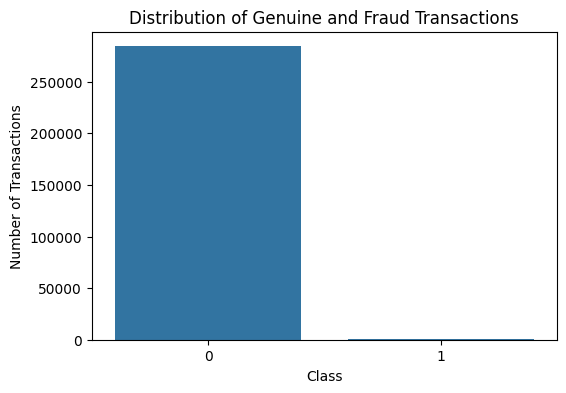

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Genuine and Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

What does this tell us?
1) Huge imbalance
2) Fraud is extremely rare
3) Accuracy alone is misleading.

In [15]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

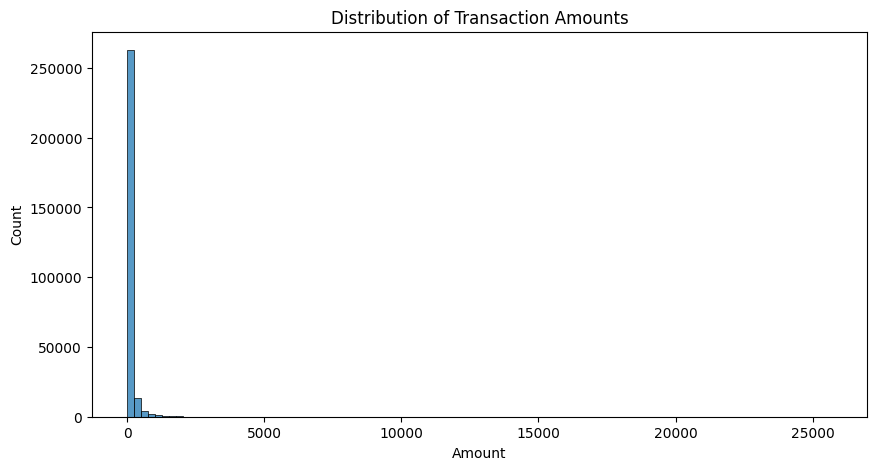

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(df["Amount"], bins=100)

plt.title("Distribution of Transaction Amounts")

plt.xlabel("Amount")

plt.show()

Explanation - Most transactions are small with few large ones this is right skewed distribution.

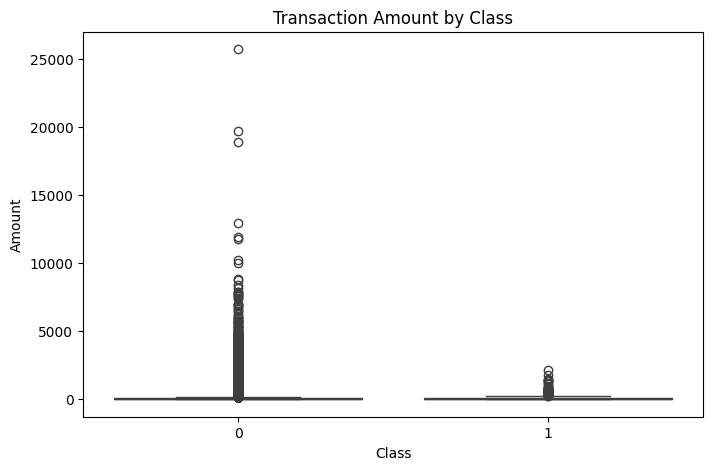

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Class", y="Amount")

plt.title("Transaction Amount by Class")

plt.show()

Explanation - We are checking if there is relation in Amount and Fraud.

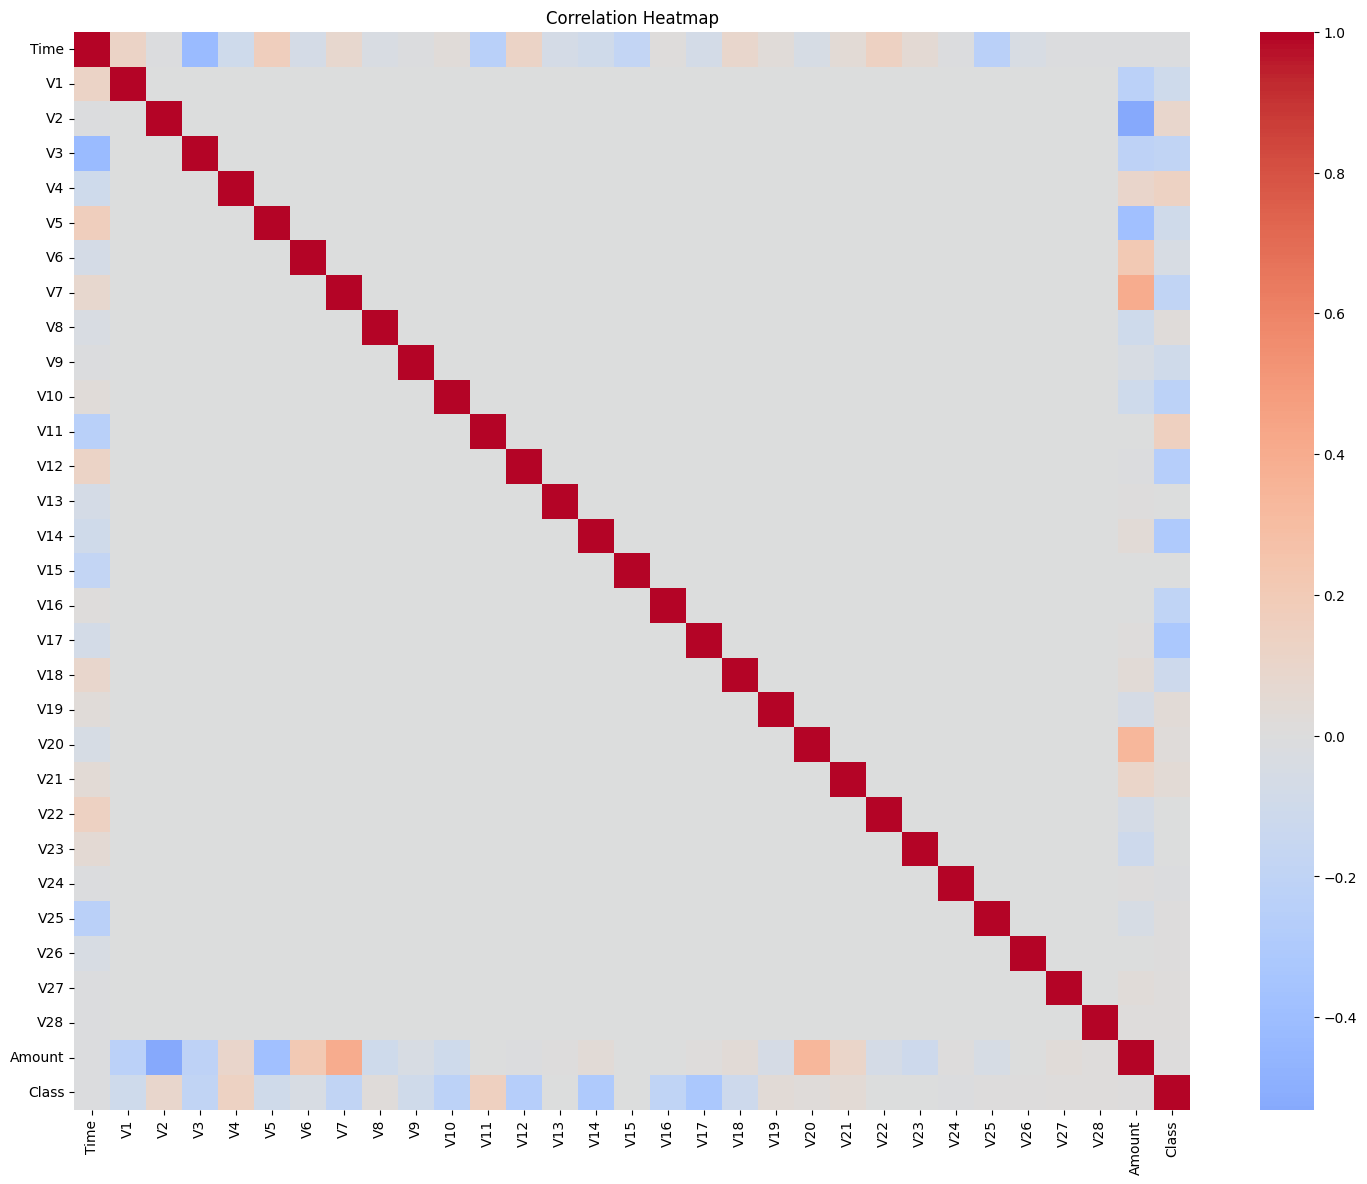

In [18]:
plt.figure(figsize=(18,14))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

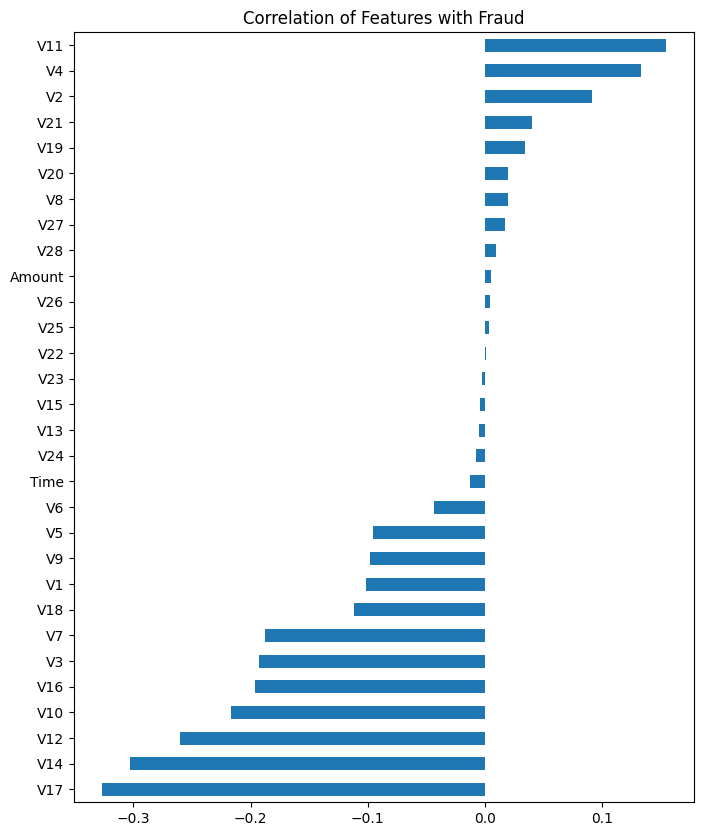

In [19]:
corr = df.corr()["Class"].sort_values()

plt.figure(figsize=(8,10))
corr.drop("Class").plot(kind="barh")
plt.title("Correlation of Features with Fraud")
plt.show()

Explanation - We are trying to find correlation of features with target class.

Splitting data to train models

In [20]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(227845, 30)
(56962, 30)
Class
0    227451
1       394
Name: count, dtype: int64
Class
0    56864
1       98
Name: count, dtype: int64


Observation - The dataset was split into 80% traning and 20% testing using stratified sampling

Using stratify= y ensure that proportions of fraudulent and genuine transactions remained nearly identical.This is important as dataset is highy imbalanced.

Now comes scaling why is it nessacary and for which model

1)Logistic regression - why, because it is a simple , fast and a baseline model for a classification algorithm. It can learn simple patterns.This is a Linear Model.

2)Random Forest - Why , because it can handle complex data and ineteractions between features.Performs better on tabular data like this one and Dosent require feature scaling.This is a non linear model.


Dummy classifier(Baseline)-

In [23]:
dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

In [24]:
print("Accuracy :", accuracy_score(y_test, dummy_pred))
print("Precision:", precision_score(y_test, dummy_pred))
print("Recall   :", recall_score(y_test, dummy_pred))
print("F1 Score :", f1_score(y_test, dummy_pred))

Accuracy : 0.9982795547909132
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


So we got 99% accuracy how does a dummy gets this accuracy. What happened was it just guessed the most frequent occuring answer and as our dataset has most of genuine transaction it got fooled and guessed all as genuine which showed accuracy as 99%.

Conclusion-  This shows that accuracy is not the only and correct parameter to judge the performance we need other parameters like Precisin,Recall , F1 score.

Logistic Regression-

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [26]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(227845, 30)
(56962, 30)


In [27]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

In [28]:
print("Accuracy :", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall   :", recall_score(y_test, log_pred))
print("F1 Score :", f1_score(y_test, log_pred))
print("ROC-AUC  :", roc_auc_score(y_test, log_pred))

Accuracy : 0.9991397773954567
Precision: 0.8266666666666667
Recall   : 0.6326530612244898
F1 Score : 0.7167630057803468
ROC-AUC  : 0.8162122227900727


In [29]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



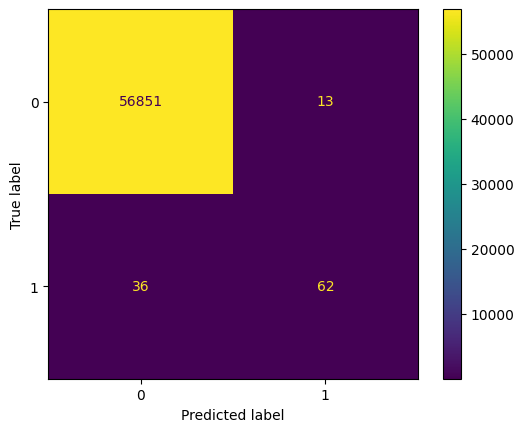

In [30]:
cm = confusion_matrix(y_test, log_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

The Logistic Regression model achieved an overall accuracy of 99.91%. However, due to the highly imbalanced nature of the dataset, accuracy alone is not sufficient. The model achieved a precision of 82.67%, meaning most transactions predicted as fraud were indeed fraudulent. Its recall was 63.27%, indicating that it successfully detected nearly two-thirds of all fraudulent transactions while missing the remaining fraud cases. This highlights the need for techniques such as SMOTE or more advanced models to improve fraud detection performance.

Remember the dummy classifier the accuracy is similler but we see that the most important of all that is Recall which shows that out of actually frauds how many were correctly predicted which was given 0 by dummy and here we got improvement.This is why banks rely on Recall score.

Next up we will use a more complex non linear model Random forest think of it like asking many small yes and no questions to a 1000 people before coming to a decision. We will hope to increase the Recall and F1 score which is bascially average of recall and Precision.

#Random Forest-

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [32]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_pred))

Accuracy : 0.9995962220427653
Precision: 0.9411764705882353
Recall   : 0.8163265306122449
F1 Score : 0.8743169398907104
ROC-AUC  : 0.9081193007591333


In [33]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



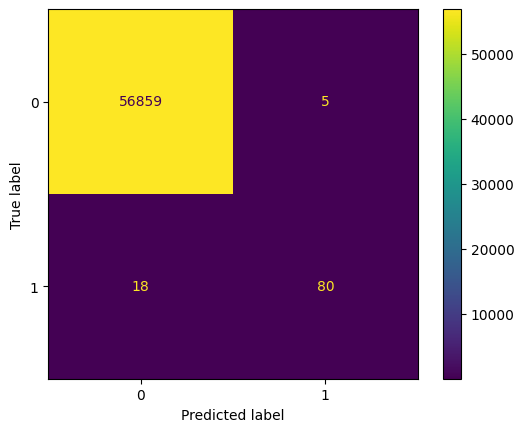

In [34]:
cm = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.show()

##MODEL COMPARISION##

Both Logistic regression and Random Forest performed well in terms of overall accuracy.
However, because the dataset is highly imbalanced,metrics such as Precision,Recall, F1-score, and ROC-AUC provide a better measure of model performance.
Random Forest outperformed Logistic Regression across all evaluation metrics.In particular, it achieved a Recall of 81.63% compared to 63.2% for losgistic regression it detected substantially more fraud transaction.

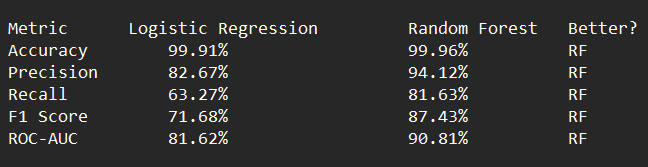

The test set had 98 fraud transactions
Logistic Regression caught approx 62
Random Forest caught approx 80

For a bank this is a huge difference

Reason - Why did Random Forest performe better this happened as Logistic regression is a linear model but many times datasets dont have direct linear relation while Random Forest is a non linear model which is better when it comes to finding complex relations.

SMOTE - Synthetic Minority Over-sampling Technique

We see that our model has only 394 fraud cases during training which is small what if we could give it more fraud samples 

We generate fraud using this technique
Example - 
fraud A
age - 25
amount - 1200

fraud B
age 30
amount - 1000

Using smote we can generate 
another fraud C
age 27
amount - 1100.

##install imbalance learn##

!pip install imbalanced-learn

In [35]:
##install imbalance learn##

!pip install imbalanced-learn

In [36]:
from imblearn.over_sampling import SMOTE

In [37]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [38]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64
Class
0    227451
1    227451
Name: count, dtype: int64


We see now that we have many more fraud on which we can train.

In [39]:
rf_smote = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [40]:
rf_smote_pred = rf_smote.predict(X_test)

In [41]:
print("Accuracy :", accuracy_score(y_test, rf_smote_pred))
print("Precision:", precision_score(y_test, rf_smote_pred))
print("Recall   :", recall_score(y_test, rf_smote_pred))
print("F1 Score :", f1_score(y_test, rf_smote_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_smote_pred))

Accuracy : 0.999420666409185
Precision: 0.8350515463917526
Recall   : 0.826530612244898
F1 Score : 0.8307692307692308
ROC-AUC  : 0.913124619572083


In [42]:
print(classification_report(y_test, rf_smote_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



OBSERVATION - 

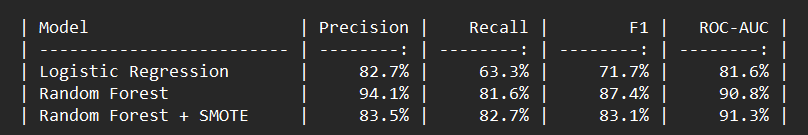

Here we see that even though we improved recall but that means we were able to catch 1 more fraud but it reduced the precision means the model started giving more false which reduced the precision score and since F1 score takes in account both precision and recall it reduced by 4%  

So even tho we thought using SMOTE will actually increace the overall score but it turns out Random Forest is much more robust that using SMOTE. 

Bagging & Boosting

Bagging trains multiple models independently on different bootstrap samples of the data and combines their predictions, usually by voting. Its goal is to reduce variance and improve stability. Random Forest is a classic example.

Boosting trains models sequentially. Each new model focuses on correcting the mistakes made by the previous ones. Its goal is to build a stronger learner by improving errors step by step. XGBoost is a popular boosting algorithm.

The models we used till now were 
1) Logistic regression - a simple linear baseline
2) Random Forest - Non linear Bagging Model

   now we will try using
 **XGBoost - Boosting Model**

In [43]:
!pip install -q xgboost

In [44]:
from xgboost import XGBClassifier

In [45]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [46]:
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_pred))

Accuracy : 0.9994908886626171
Precision: 0.9156626506024096
Recall   : 0.7755102040816326
F1 Score : 0.8397790055248618
ROC-AUC  : 0.8876935516750313


In [47]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.78      0.84        98

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



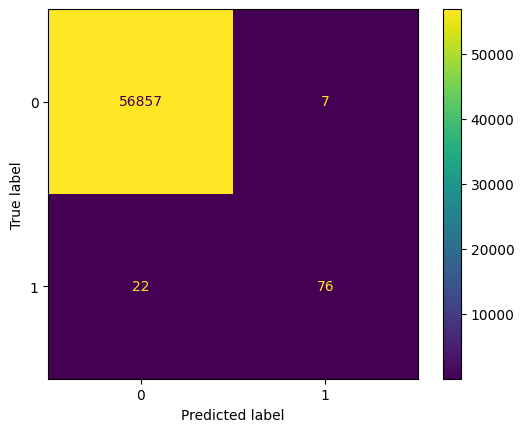

In [48]:
cm = confusion_matrix(y_test, xgb_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

OBSERVATION - 

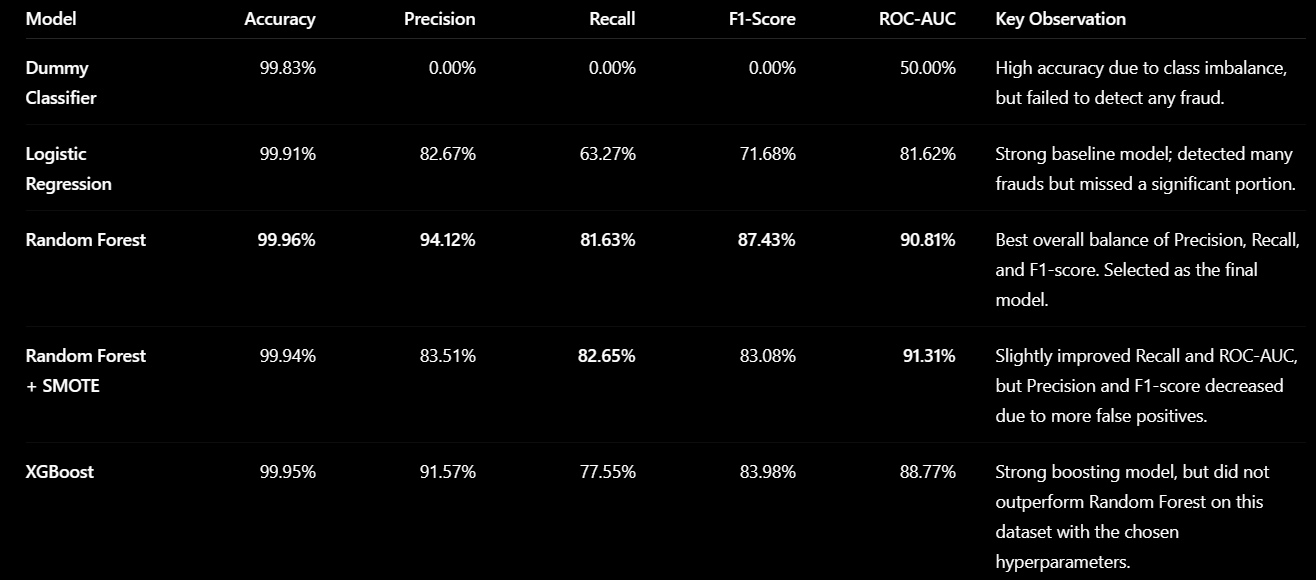

What we see here is that XGBoost which is even more complex model than any other model did not perform better than Random Forest. Why did this happen 
1) We did not optimize it for data notice we used
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6

   but there are lot many important parameter that can affect performance

2) data is already well cleaned and tabulated noise is reduced , feature relationships are cleaner and there is no reduntant information Random Forest performes vell on this type of data


3) The dataset is not huge enough for XGBoost so there was no room for improvment for XGBoost   

Fine tuning XGBoost 

In [57]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [58]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1]
}

In [59]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [60]:
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200]},
             scoring='f1', verbose=1)

In [61]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
0.8411158301637206


In [63]:
best_xgb = grid_search.best_estimator_

xgb_pred = best_xgb.predict(X_test)

In [64]:
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

Accuracy : 0.9994908886626171
Precision: 0.9058823529411765
Recall   : 0.7857142857142857
F1 Score : 0.8415300546448088
ROC-AUC  : 0.8927867995819599
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.79      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



OBSERVATION - 

Hyperparameter tuning was performed on XGBoost model using GridSearchCV to optimize values of learning rate , max depth , and n_estimator. The best performance obtained was LR = 0.1 ,max_dept = 5 and n_estimators = 200. The tuned model showed slight improvement in Recall, F1 score and ROC-AUC compared to default XGBoost model.However it still did not outperforme the Random Forest, which is still the overall balance of Precision,Recall and F1 score.Therefore, Random Forest was retained as the final model.

Feature Importance 

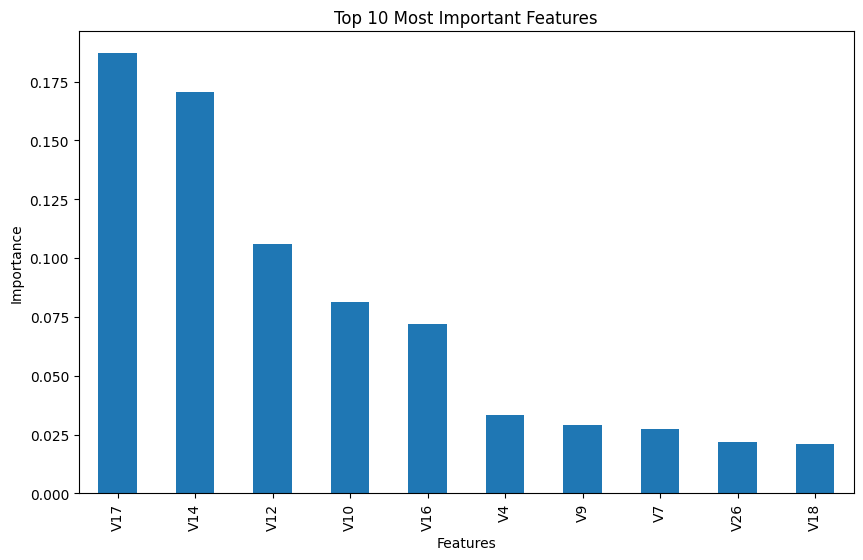

In [65]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')
plt.title("Top 10 Most Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

Random Forest provides feature importance score based on the reduction in impurity contributed by each feature across all decision trees.This analysis highlights which transformed features contribute most to fraud detection.

ROC Curve

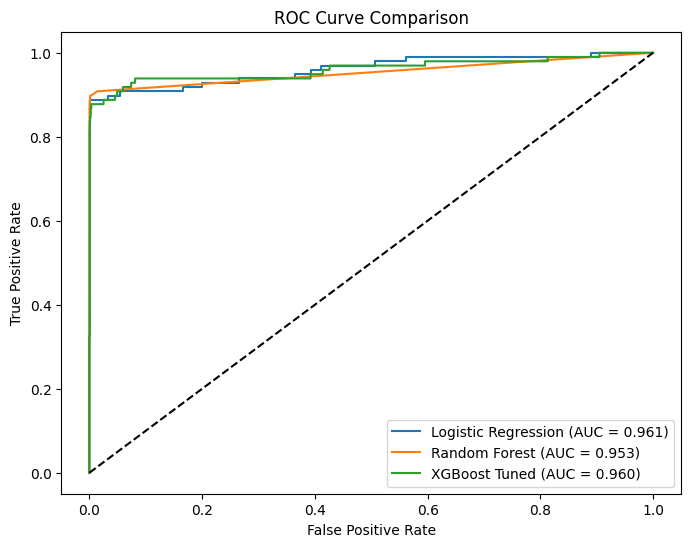

In [66]:
from sklearn.metrics import roc_curve, auc

# Logistic Regression
log_probs = log_model.predict_proba(X_test_scaled)[:,1]
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
roc_auc_log = auc(fpr_log, tpr_log)

# Random Forest
rf_probs = rf_model.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Tuned XGBoost
xgb_probs = best_xgb.predict_proba(X_test)[:,1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log,
         label=f'Logistic Regression (AUC = {roc_auc_log:.3f})')

plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC = {roc_auc_rf:.3f})')

plt.plot(fpr_xgb, tpr_xgb,
         label=f'XGBoost Tuned (AUC = {roc_auc_xgb:.3f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Although Logistic Regression achieved the highest ROC-AUC, Random Forest was selected as the final model because it provided the best balance of Precision, Recall, and F1-score on this highly imbalanced dataset.

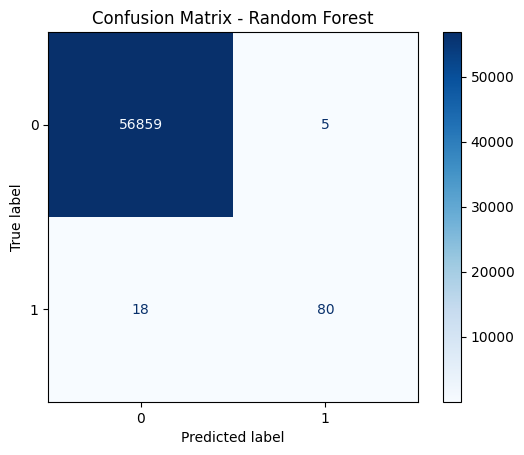

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

Final comparision matrix

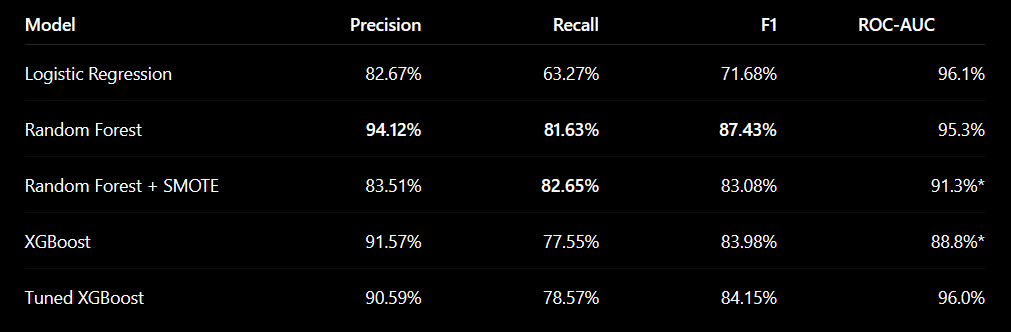

CONCLUSION

This project developed and evaluated multiple machine learning models for credit card fraud detection on a highly imbalanced dataset. Logistic Regression was used as the baseline model, followed by Random Forest, Random Forest with SMOTE, XGBoost, and a hyperparameter-tuned XGBoost model. Performance was evaluated using Precision, Recall, F1-score, and ROC-AUC rather than Accuracy due to the severe class imbalance. Among all evaluated models, Random Forest achieved the best overall balance of fraud detection capability and false alarm reduction, making it the most suitable model for this dataset. The project demonstrates the importance of systematic model comparison and objective evaluation in solving real-world fraud detection problems.

FUTURE WORK

1)Explore LightGBM and CatBoost for tabular fraud detection.

2)Apply SHAP for model explainability.

3)Experiment with threshold optimization for different business requirements.

4)Build a real-time fraud detection pipeline using streaming transaction data.

5)Investigate deep learning and transformer-based fraud detection models.